# Module 2 - Quantum Teleportation

In [33]:
import os
import math
import numpy as np
import qiskit
from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer, AerSimulator
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit.transpiler import generate_preset_pass_manager

from qiskit.visualization import array_to_latex, plot_histogram
from IPython.display import display


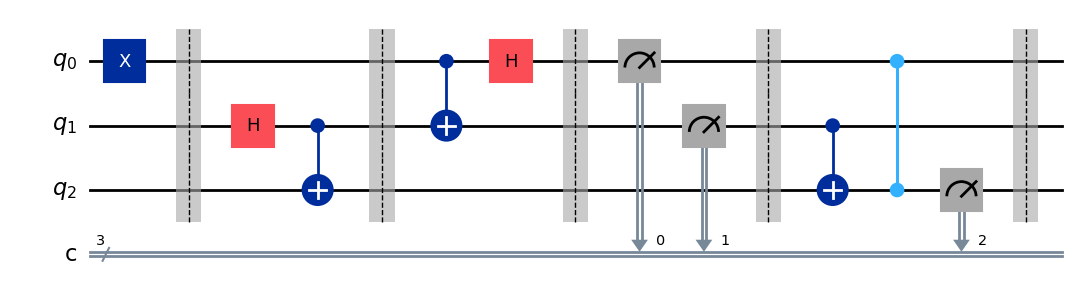

In [22]:
circuit = QuantumCircuit(3, 3)
circuit.x(0)
circuit.barrier()

circuit.h(1)
circuit.cx(1, 2)
circuit.barrier()

circuit.cx(0, 1)
circuit.h(0)
circuit.barrier()

circuit.measure([0, 1], [0, 1])
circuit.barrier()

circuit.cx(1, 2)
circuit.cz(0, 2)
circuit.measure(2, 2)
circuit.barrier()


circuit.draw('mpl')


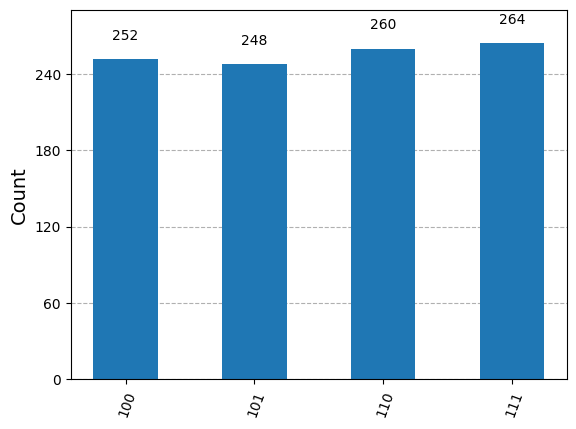

In [23]:
simulator = AerSimulator()
compiled_circuit = transpile(circuit, simulator)
job = simulator.run(compiled_circuit)
result = job.result()
counts = result.get_counts(compiled_circuit)

display(qiskit.visualization.plot_histogram(counts))

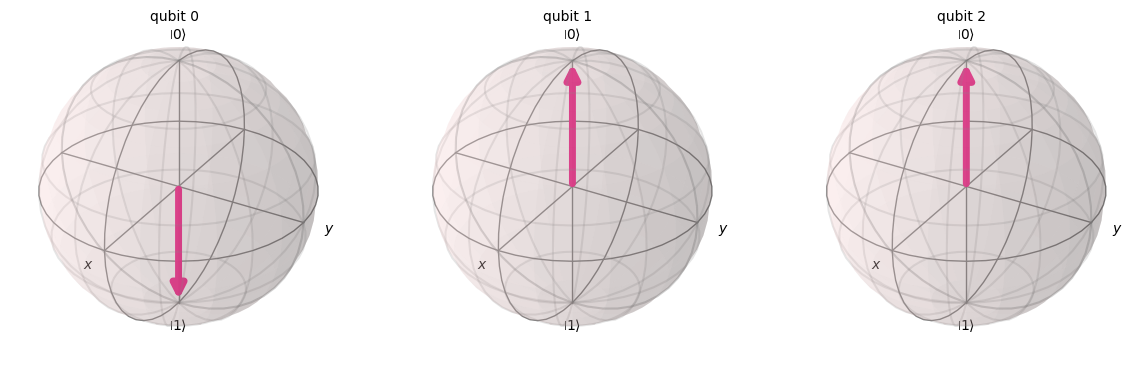

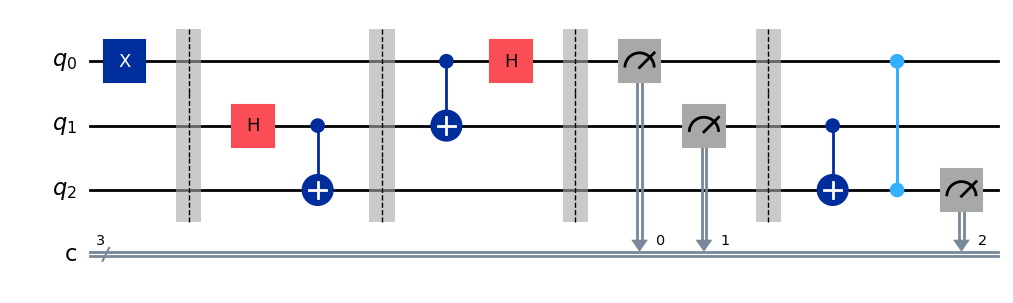

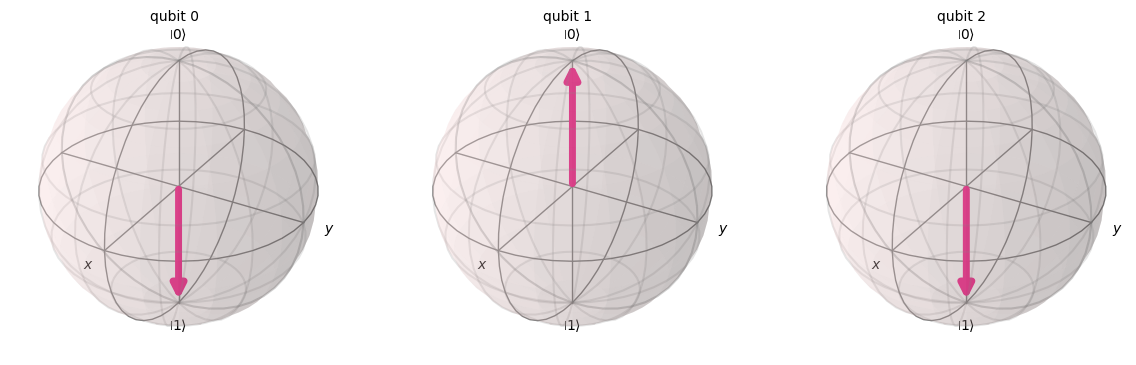

In [32]:
def teleport_state(circuit):

    statevector_simulator = Aer.get_backend('statevector_simulator')
    statevec_job = statevector_simulator.run(circuit)
    result = statevec_job.result()
    statevec_org = result.get_statevector()

    circuit.barrier()

    circuit.h(1)
    circuit.cx(1, 2)
    circuit.barrier()

    circuit.cx(0, 1)
    circuit.h(0)
    circuit.barrier()

    circuit.measure([0, 1], [0, 1])
    circuit.barrier()

    circuit.cx(1, 2)
    circuit.cz(0, 2)

    statevec_job = statevector_simulator.run(circuit)
    result = statevec_job.result()
    statevec = result.get_statevector()


    circuit.measure(2, 2)

    simulator = AerSimulator()
    compiled_circuit = transpile(circuit, simulator)
    job = simulator.run(compiled_circuit)
    result = job.result()
    counts = result.get_counts(compiled_circuit)


    return statevec_org, statevec, counts, circuit



def display_teleportation_results(statevec_org, statevec, counts, circuit):
    display(qiskit.visualization.plot_bloch_multivector(statevec_org))
    display(circuit.draw('mpl'))
    display(qiskit.visualization.plot_bloch_multivector(statevec))



circuit = QuantumCircuit(3, 3)
circuit.x(0)

statevec_org, statevec, counts, circuit = teleport_state(circuit)
display_teleportation_results(statevec_org, statevec, counts, circuit)

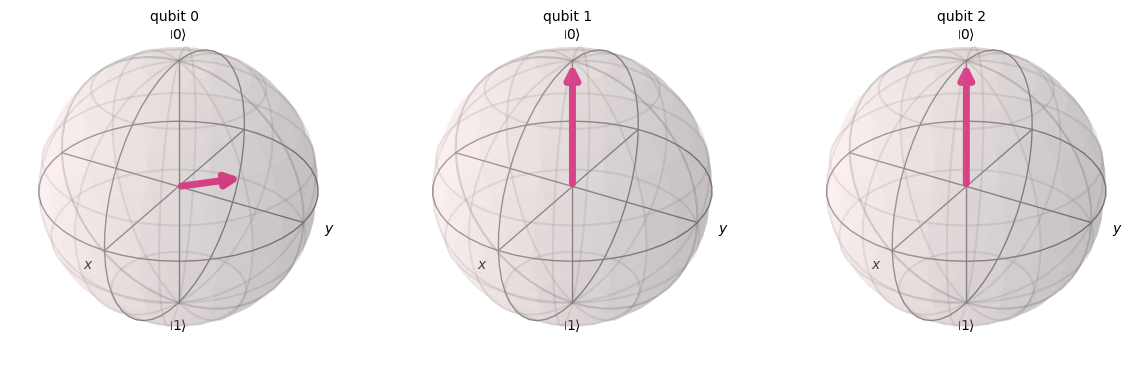

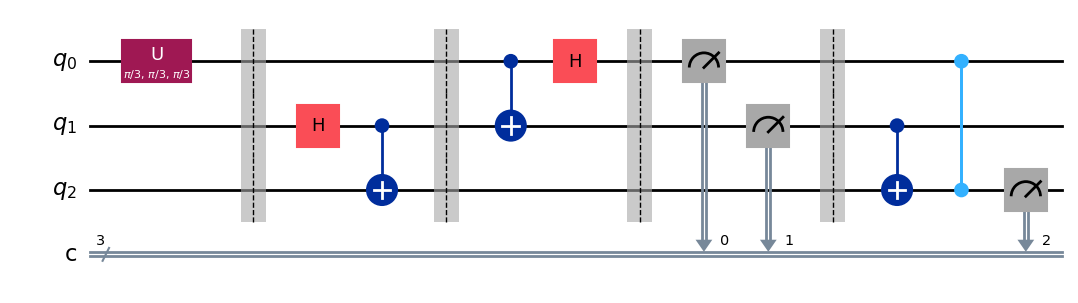

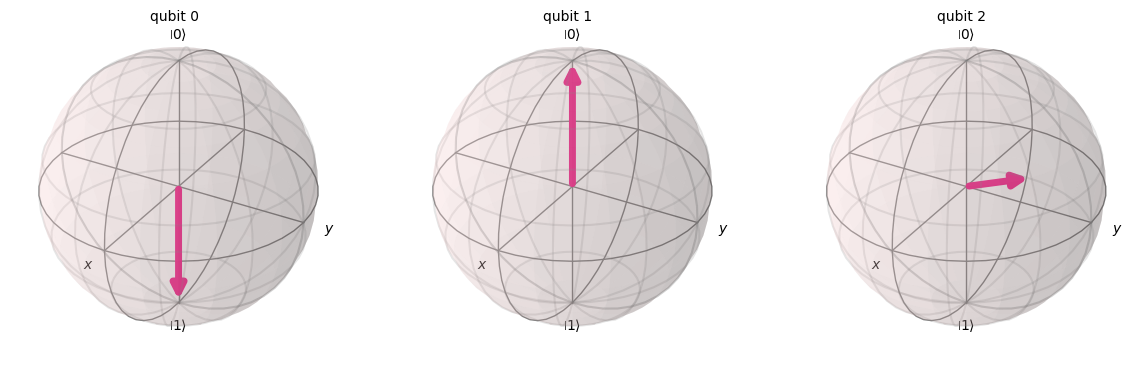

In [49]:
theta = math.pi / 3
phi = math.pi / 3
lambda_ = math.pi / 3
# let's try to teleport a more fancy state
circuit = QuantumCircuit(3, 3)
circuit.u(theta, phi, lambda_, 0)

statevec_org, statevec, counts, circuit = teleport_state(circuit)
display_teleportation_results(statevec_org, statevec, counts, circuit)